# Right patch

## Libraries and functions

In [ ]:
import pickle
import yaml
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
import seaborn as sns
from astropy.time import Time

from qubic.lib.Qsamplings import gal2equ

import snr_analysis_functions as sf
import visibility_functions as vf

In [ ]:
# See snr_analysis_functions.py
# See visibility_functions.py

def load_maps(file, plot=False):
    data = pickle.load(open(file, "rb"))

    nus = data["nus"]
    Nrec = nus.shape[0] - 7

    maps_input = data["maps_in_convolved"]
    maps_rec = data["maps"][:Nrec]
    maps_res = maps_input - maps_rec
    maps_noise = data['maps_noise'][:Nrec]

    center = data["center"]
    coverage = data["coverage"]
    seenpix = data["seenpix"]

    maps_input[:, ~seenpix, :] = hp.UNSEEN
    maps_rec[:, ~seenpix, :] = hp.UNSEEN
    maps_res[:, ~seenpix, :] = hp.UNSEEN

    if plot==True:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        hp.mollview(coverage, title='Coverage', cmap='Spectral_r', fig=fig.number, sub=(1, 2, 1))
        plt.subplot(1, 2, 1).axis('off')

        axes[1].plot(data["convergence"])
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("Convergence")
        axes[1].set_title("PCG Convergence")
        axes[1].set_yscale("log")
        axes[1].set_ylim(1e-8, 1e0)
        axes[1].grid()

        plt.subplots_adjust(wspace=0.4)
        plt.show()

        STOKES = ["I", "Q", "U"]

        istk = 0
        n = 2
        reso = 15

        k = 0

        plt.figure(figsize=(20, 10))
        for inu in range(Nrec):
            hp.gnomview((maps_input[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                                cmap="jet",
                                # min = - n * sigma_input[inu],
                                # max = n * sigma_input[inu],
                                sub=(Nrec, 3, k + 1))
            
            hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                                cmap="jet",
                                # min = - n * sigma_rec[inu],
                                # max = n * sigma_rec[inu],
                                sub=(Nrec, 3, k + 2))
            
            hp.gnomview(maps_res[inu, :, istk], rot=center,
                                reso=reso,
                                notext=True,
                                title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                                cmap="jet",
                                # min = - n * sigma_res[inu],
                                # max = n * sigma_res[inu],
                                sub=(Nrec, 3, k + 3))
            k += 3

    del data

    return maps_input[:,:,0], maps_rec[:,:,0], maps_res[:,:,0], center, seenpix, coverage


def maps_stacking(datafiles):
    nfiles = len(datafiles)

    # Carico il primo file per ottenere shape e metadati
    with open(datafiles[0], "rb") as f:
        data = pickle.load(f)
    nus = data["nus"]
    Nrec = nus.shape[0] - 7
    center = data["center"]

    # Preallocazione
    maps_input_arr = np.empty((nfiles, *data["maps_in_convolved"][:, :, 0].shape), dtype=np.float32)
    maps_input_nobeam_arr = np.empty((nfiles, *data["maps_in"][:, :, 0].shape), dtype=np.float32)
    maps_rec_arr   = np.empty((nfiles, *data["maps"][:Nrec, :, 0].shape), dtype=np.float32)
    coverage_arr   = np.empty((nfiles, *data["coverage"].shape), dtype=np.float32)
    seenpix_arr   = np.empty((nfiles, *data["seenpix"].shape), dtype=bool)

    # Inserisco il primo file
    maps_input_arr[0] = data["maps_in_convolved"][:, :, 0]
    maps_input_nobeam_arr[0] = data["maps_in"][:, :, 0]
    maps_rec_arr[0]   = data["maps"][:Nrec, :, 0]
    coverage_arr[0]   = data["coverage"]
    seenpix_arr[0]    = data["seenpix"]

    # Leggo il resto dei file
    for i, fname in enumerate(datafiles[1:], start=1):
        with open(fname, "rb") as f:
            data = pickle.load(f)
        maps_input_arr[i] = data["maps_in_convolved"][:, :, 0]
        maps_input_nobeam_arr[i] = data["maps_in"][:, :, 0]
        maps_rec_arr[i]   = data["maps"][:Nrec, :, 0]
        coverage_arr[i]   = data["coverage"]
        seenpix_arr[i]    = data["seenpix"]

    # Calcolo medie cumulative
    maps_input_cum = np.cumsum(maps_input_arr, axis=0) / np.arange(1, nfiles + 1)[:, None, None]
    maps_input_nobeam_cum = np.cumsum(maps_input_nobeam_arr, axis=0) / np.arange(1, nfiles + 1)[:, None, None]
    maps_rec_cum   = np.cumsum(maps_rec_arr, axis=0) / np.arange(1, nfiles + 1)[:, None, None]
    maps_res_cum   = maps_input_cum - maps_rec_cum

    # Coverage cumulativa e maschera
    coverage_cum = np.cumsum(coverage_arr, axis=0)
    seenpix_cum = coverage_cum / np.max(coverage_cum, axis=1)[:, None] > 0.1

    del data

    return {
        "maps_in": maps_input_arr,
        "maps_in_nobeam": maps_input_nobeam_arr,
        "maps_rec": maps_rec_arr,
        "maps_res": maps_input_arr - maps_rec_arr,
        "maps_in_cum": maps_input_cum,
        "maps_in_nobeam_cum": maps_input_nobeam_cum,
        "maps_cum": maps_rec_cum,
        "maps_res_cum": maps_res_cum,
        "nus": nus,
        "coverage": coverage_arr,
        "coverage_cum": coverage_cum,
        "center": center,
        "seenpix": seenpix_arr,
        "seenpix_cum": seenpix_cum,
    }


def load_tods(datafiles):
    nfiles = len(datafiles)
    tods = []

    for i in range(nfiles):
        with open(datafiles[i], "rb") as f:
            data = pickle.load(f)
        idx = int(np.sum(data['coverage'])/248)
        tods.append(data['tod'][0:idx])
    
        del data

    return tods


def noise_estimation(maps_input, maps_res, coverage, seenpix):
    noises = []

    # Method 1: noise as residual weighted std
    weighted_mean = np.average(maps_res[seenpix], weights=coverage[seenpix])
    weighted_std = np.sqrt( np.sum(coverage[seenpix] * (maps_res[seenpix] - weighted_mean)**2) / np.sum(coverage[seenpix]) )
    print('Residual weighted std', weighted_std)
    noises.append(weighted_std)

    snr = maps_input/weighted_std
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Weighted std",
                        cmap="jet",
                        min = 0,
    )


    # Method 2: noise estimation from a hit-count–normalized residual map
    normalized_residuals = maps_res[seenpix] * np.sqrt(coverage[seenpix])
    sigma0 = np.std(normalized_residuals)
    sigma = np.zeros_like(coverage)
    sigma[seenpix] = sigma0 / np.sqrt(coverage[seenpix])
    noises.append(sigma)

    snr = maps_input / sigma 
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Hit count normalized std",
                        cmap="jet",
                        min = 0,
    )

    
    # Method 3: noise estimation from hit-binned residual map
    nbins = 20
    hits = coverage[seenpix]
    noise = maps_res[seenpix]
    edges = np.quantile(hits, np.linspace(0, 1, nbins + 1))    # bin edges

    hits_centers = []
    sigma_bins = []

    for i in range(nbins):
        sel = (hits >= edges[i]) & (hits < edges[i+1])
        if np.sum(sel) < 50:
            continue
        hits_centers.append(np.mean(hits[sel]))
        sigma_bins.append(np.sqrt(np.mean(noise[sel]**2)))

    hits_centers = np.array(hits_centers)
    sigma_bins = np.array(sigma_bins)

    bin_idx = np.digitize(coverage[seenpix], edges) - 1  # returns 0..nbins-1
    bin_idx[bin_idx == nbins] = nbins-1     # last bin includes pixel on border
    sigma = np.zeros_like(coverage)       
    sigma[seenpix] = sigma_bins[bin_idx]
    noises.append(sigma)

    snr = maps_input / sigma
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Hit binned std",
                        cmap="jet",
                        min = 0,
    )

    
    # Method 4: noise as local std
    radius_deg = 1
    radius_rad = np.radians(radius_deg)

    sigma = np.zeros_like(maps_res)

    for ipix in range(len(maps_res)):
        # finds all the pixel within radius_rad from pixel ipix 
        neighbors = hp.query_disc(128, hp.pix2vec(128, ipix), radius_rad)
        
        # local std
        sigma[ipix] = np.sqrt(np.mean(maps_res[neighbors]**2))
    noises.append(sigma)

    snr = maps_input / sigma
    snr[~seenpix] = hp.UNSEEN
    hp.gnomview(snr, rot=center,
                        reso=15,
                        notext=True,
                        title="Local std",
                        cmap="jet",
                        min = 0,
    )

    return noises


def daily_observing_time(time_s, date_obs, max_gap_s=10.0):
    """
    Compute total observing time per day from a stream of pointing timestamps.

    Parameters
    ----------
    time_s : array-like of float
        Pointing times in seconds relative to `date_obs`.
    date_obs : astropy.time.Time
        Reference absolute time corresponding to zero in `time_s`.
    max_gap_s : float, optional
        Maximum allowed gap (in seconds) between two consecutive pointings to
        treat them as continuous observing. Larger gaps are treated as non-observing
        periods and are excluded. Default is 10.0.

    Returns
    -------
    days : astropy.time.Time
        One timestamp per observed day, at 00:00:00 of that day.
    sec_day : numpy.ndarray
        Total observing time per day in seconds 
    """
    u = date_obs.unix + time_s

    # Keep only consecutive intervals that represent continuous observing
    dt = np.diff(u)
    valid = (dt > 0.0) & (dt <= float(max_gap_s))
    if not np.any(valid):
        return Time([], format="unix", scale=t.scale), np.array([], dtype=float)

    # Start/end times of valid intervals
    starts = u[:-1][valid]
    ends = u[1:][valid]

    # Day index for each interval start/end.
    d0 = (starts // 86400.0).astype(np.int64)
    d1 = (ends // 86400.0).astype(np.int64)

    dmin = d0.min()
    dmax = d1.max()
    nday = int(dmax - dmin + 1)

    sec_day = np.zeros(nday, dtype=float)

    # Intervals fully inside one day: add full duration to that day.
    same = (d0 == d1)
    if np.any(same):
        idx = d0[same] - dmin
        sec_day += np.bincount(idx, weights=ends[same] - starts[same], minlength=nday)

    # Intervals crossing midnight: split contribution across two days.
    cross = ~same 
    if np.any(cross):
        midnight = (d0[cross] + 1) * 86400.0
        sec_day += np.bincount(d0[cross] - dmin, weights=midnight - starts[cross], minlength=nday)
        sec_day += np.bincount(d1[cross] - dmin, weights=ends[cross] - midnight, minlength=nday)

    # Keep only days with non-zero observing time.
    keep = sec_day > 0.0
    day_idx = np.arange(dmin, dmax+1, dtype=np.int64)[keep]
    days = Time(day_idx * 86400.0, format='unix', scale=date_obs.scale)
    days.format = 'iso'

    return days, sec_day[keep]


def snr_from_coverage_bins(maps_input, maps_res, coverage, seenpix, center=[0, 0], nbins=20, plot=False, verbose=False):
    """
    Estimate binned noise (sigma) and SNR based on coverage quantiles.

    Inputs:
        maps_input : 1D array
            Input map 
        maps_res : 1D array
            Residual map
        coverage : 1D array
            Coverage map used to bin pixels.
        seenpix : 1D bool array or index array
            Mask of observed pixels.
        center : list
            Center used only for plotting.
        nbins : int
            Number of coverage bins (quantiles).
        plot : bool
            If True, plot the SNR map.

    Outputs:
        snr : 1D array
            Signal-to-noise map (maps_input / sigma).
        sigma : 1D array
            Binned RMS noise per pixel (constant within each coverage bin).
        corr_cov_sigma : float
            Correlation between coverage and sigma over seen pixels.
        corr_inv_sqrt_cov_sigma : float
            Correlation between 1/sqrt(coverage) and sigma over seen pixels.
    """

    hits = coverage[seenpix]
    noise = maps_res[seenpix]
    edges = np.quantile(hits, np.linspace(0, 1, nbins + 1))  # bin edges

    hits_centers = []
    sigma_bins = np.full(nbins, np.nan, dtype=float)

    for i in range(nbins):
        sel = (hits >= edges[i]) & (hits < edges[i + 1])
        if np.sum(sel) < 50:
            continue
        hits_centers.append(np.mean(hits[sel]))
        sigma_bins[i] = np.sqrt(np.mean(noise[sel]**2))

    hits_centers = np.array(hits_centers)

    bin_idx = np.digitize(coverage[seenpix], edges) - 1  # 0..nbins-1
    bin_idx[bin_idx == nbins] = nbins - 1  # include right edge

    sigma = np.full_like(coverage, np.nan, dtype=float)
    sigma[seenpix] = sigma_bins[bin_idx]

    snr = maps_input / sigma

    corr_cov_sigma = 0
    corr_inv_sqrt_cov_sigma = 0
    if verbose:

        # Correlations over seen pixels (exclude NaNs)
        if np.any(~np.isfinite(sigma[seenpix])):
            raise ValueError("The noise is NaN for some pixel.")

        corr_cov_sigma = np.corrcoef(coverage[seenpix], sigma[seenpix])[0, 1]
        corr_inv_sqrt_cov_sigma = np.corrcoef(1 / np.sqrt(coverage[seenpix]), sigma[seenpix])[0, 1]

        print("Correlation between coverage and binned noise:", corr_cov_sigma)
        print("Correlation between 1/sqrt(coverage) and binned noise:", corr_inv_sqrt_cov_sigma)

    if plot:
        snr[~seenpix] = hp.UNSEEN
        hp.gnomview(snr, rot=center,
                    reso=15, notext=True, title="SNR",
                    cmap="jet", min=0)

    return snr, sigma, corr_cov_sigma, corr_inv_sqrt_cov_sigma


def snr_from_local_std(maps_input, maps_res, coverage, seenpix, center=[0, 0], radius_deg=1.0, plot=False, verbose=False):
    """
    Estimate local noise (sigma) and SNR. The nosie is computed within a disk of radius
    `radius_deg` (in degrees) centered on each pixel.

    Inputs:
        maps_input : 1D array
            Input map 
        maps_res : 1D array
            Residual map
        coverage : 1D array
            Coverage map used to bin pixels.
        seenpix : 1D bool array or index array
            Mask of observed pixels.
        center : list
            Center used only for plotting.
        radius_deg : float
            Radius (in degrees) of the circular neighborhood.
        plot : bool
            If True, plot the SNR map.

    Outputs:
        snr : 1D array
            Signal-to-noise map (maps_input / sigma).
        sigma : 1D array
            Binned RMS noise per pixel (constant within each coverage bin).
        corr_cov_sigma : float
            Correlation between coverage and sigma over seen pixels.
        corr_inv_sqrt_cov_sigma : float
            Correlation between 1/sqrt(coverage) and sigma over seen pixels.
    """
    radius_rad = np.radians(radius_deg)

    sigma = np.full_like(maps_res, np.nan, dtype=float)

    for ipix in range(len(maps_res)):
        # Find all pixels within radius_rad from ipix
        neighbors = hp.query_disc(128, hp.pix2vec(128, ipix), radius_rad)

        # Keep only observed pixels
        neighbors = neighbors[seenpix[neighbors]]
        if neighbors.size == 0:
            continue

        # Local RMS of residuals
        sigma[ipix] = np.sqrt(np.mean(maps_res[neighbors]**2))

    snr = maps_input / sigma
  

    # Correlations over seen pixels (exclude NaNs)
    if np.any(~np.isfinite(sigma[seenpix])):
        raise ValueError("The noise is NaN for some pixel.")

    corr_cov_sigma = np.corrcoef(coverage[seenpix], sigma[seenpix])[0, 1]
    corr_inv_sqrt_cov_sigma = np.corrcoef(1 / np.sqrt(coverage[seenpix]), sigma[seenpix])[0, 1]

    if verbose:
        print("Correlation between coverage and binned noise:", corr_cov_sigma)
        print("Correlation between 1/sqrt(coverage) and binned noise:", corr_inv_sqrt_cov_sigma)

    if plot:
        snr[~seenpix] = hp.UNSEEN
        hp.gnomview(snr, rot=center,
                    reso=15, notext=True, title="SNR",
                    cmap="jet", min=0)

    return snr, sigma, corr_cov_sigma, corr_inv_sqrt_cov_sigma

## Inspect maps

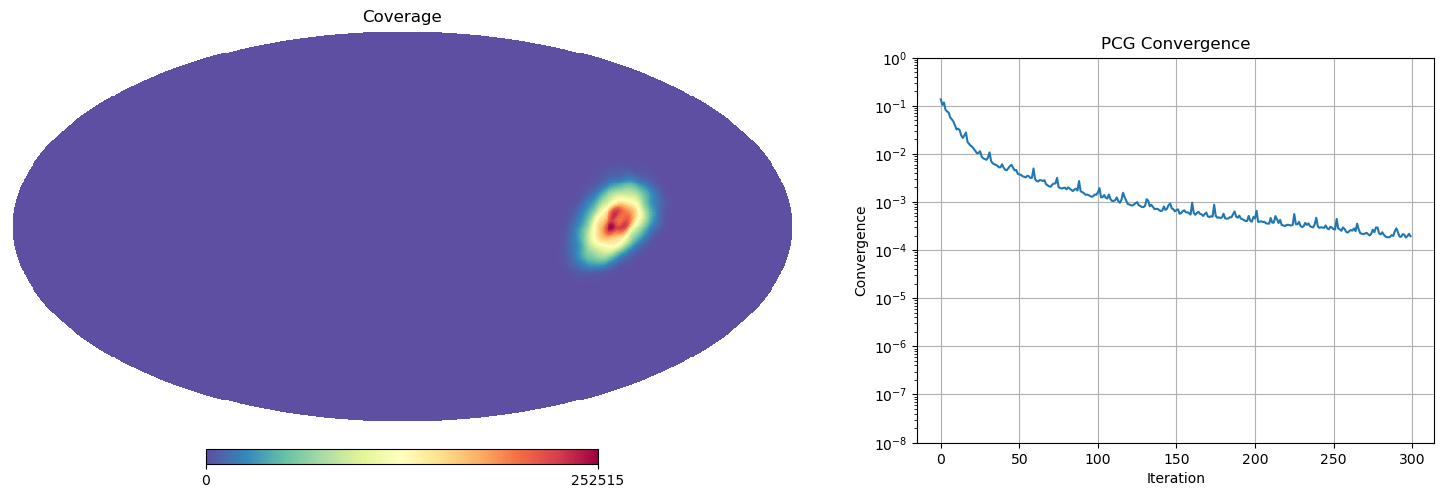

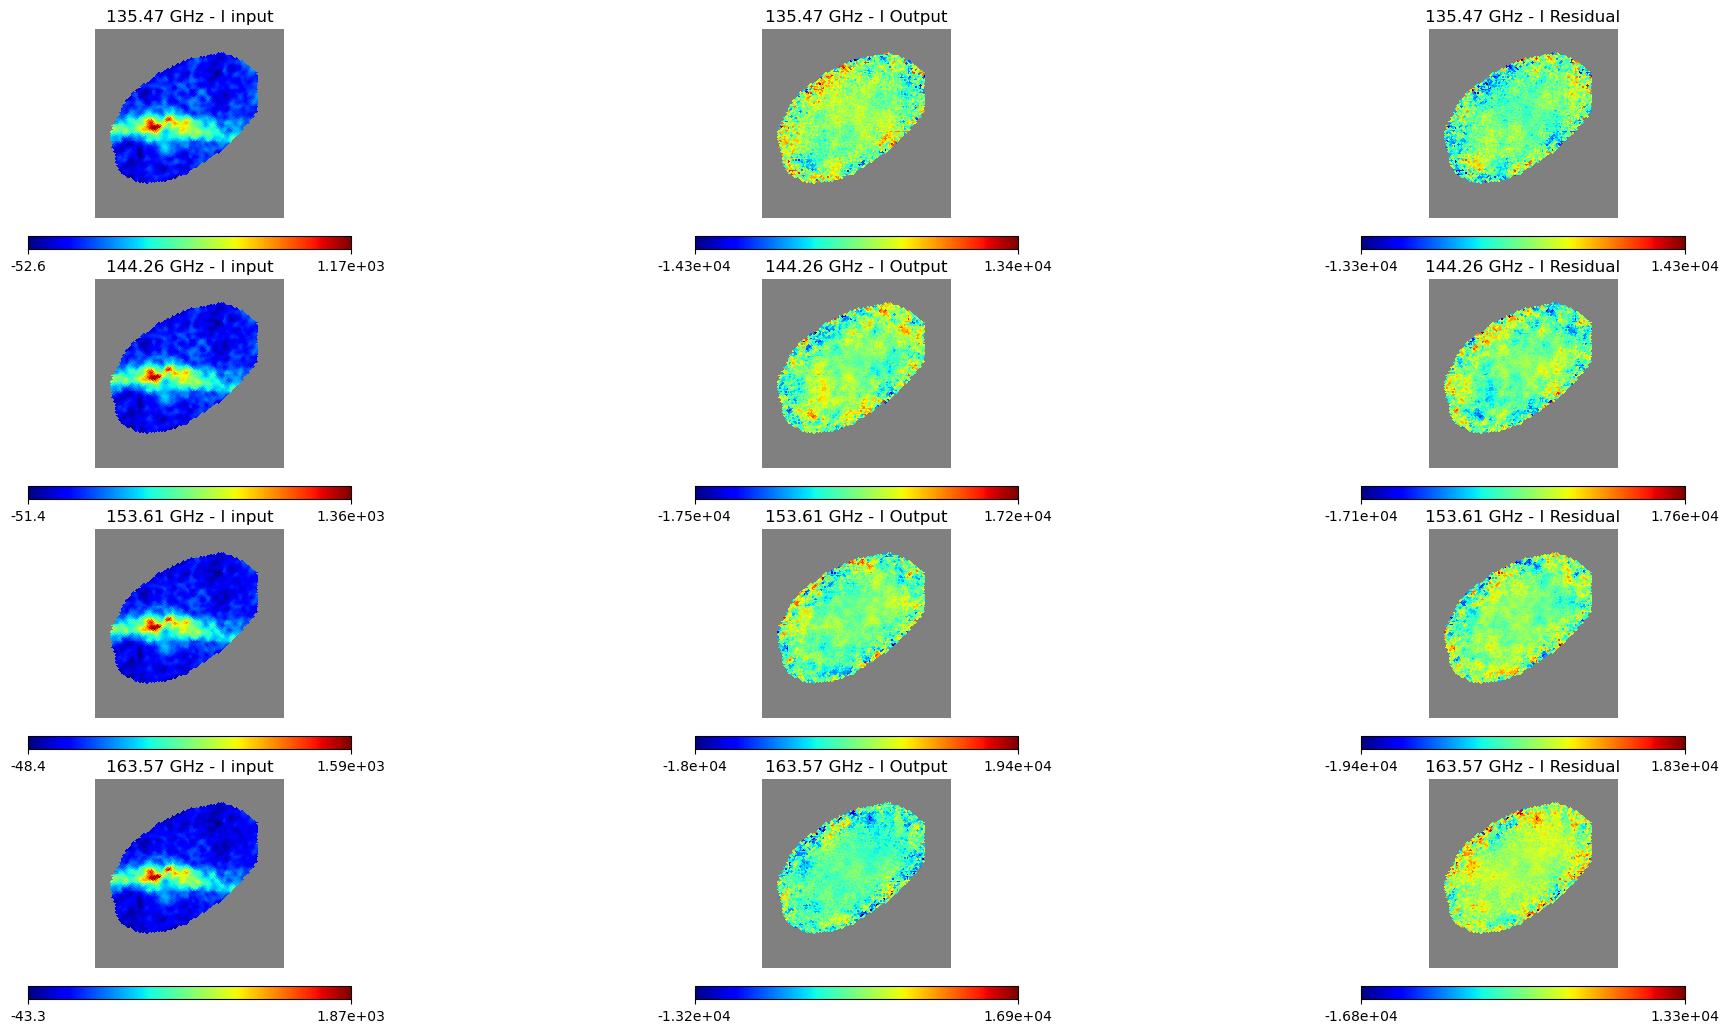

In [6]:
data = load_maps("/media/mattia/Hard Disk/data/right/maps/final/03-04.pkl", plot=True)

##  Pointings

In [3]:
# Load pointings file
pointings = []
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/right/pointings/pointings_janfeb.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/right/pointings/pointings_marapr.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/right/pointings/pointings_mayjun.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/right/pointings/pointings_julaug.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/right/pointings/pointings_sepoct.pkl", "rb")))
pointings.append(pickle.load(open("/media/mattia/Hard Disk/data/right/pointings/pointings_novdec.pkl", "rb")))

In [4]:
total_hours = 0
for pointing in pointings:
    days, sec_day = daily_observing_time(pointing.time, pointing.date_obs, max_gap_s=10.0)
    hours_day = sec_day / 3600.0
    print('Hours of observing time per day:')
    print(hours_day)
    total_hours += np.sum(hours_day)  
    print('Total observation time:', np.round(np.sum(hours_day), decimals=1), 'hours')
print('Total observation time in one year:', np.round(total_hours, decimals=1), 'hours =', np.round(total_hours/(24*365)*100, decimals=1), '%')

Hours of observing time per day:
[6.46013889 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333
 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333
 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333
 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333 7.99833333
 8.00143056 8.06388889 8.06361111 8.06388889 8.06388889 8.06388889
 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889
 8.06388889 8.06388889 8.06361111 8.06388889 8.06388889 8.06388889
 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889
 8.06388889 8.06388889 8.06361111 8.06388889 8.06388889 8.06388889
 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889 1.76801389]
Total observation time: 474.4 hours
Hours of observing time per day:
[6.295875   8.06388889 8.06388889 8.06388889 8.06361111 8.06388889
 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889
 8.06388889 8.06388889 8.06388889 8.06388889 8.06388889 8.06361111
 8.06388889 8.06388889 8.0

## Maps with realistic scanning strategy

In [3]:
datafiles=[
    "/media/mattia/Hard Disk/data/right/maps/final/01-02.pkl",
    "/media/mattia/Hard Disk/data/right/maps/final/03-04.pkl",
    "/media/mattia/Hard Disk/data/right/maps/final/05-06.pkl",
    "/media/mattia/Hard Disk/data/right/maps/final/07-08.pkl",
    "/media/mattia/Hard Disk/data/right/maps/final/09-10.pkl",
    "/media/mattia/Hard Disk/data/right/maps/final/11-12.pkl",
]

N = len(datafiles)

In [4]:
data = maps_stacking(datafiles)

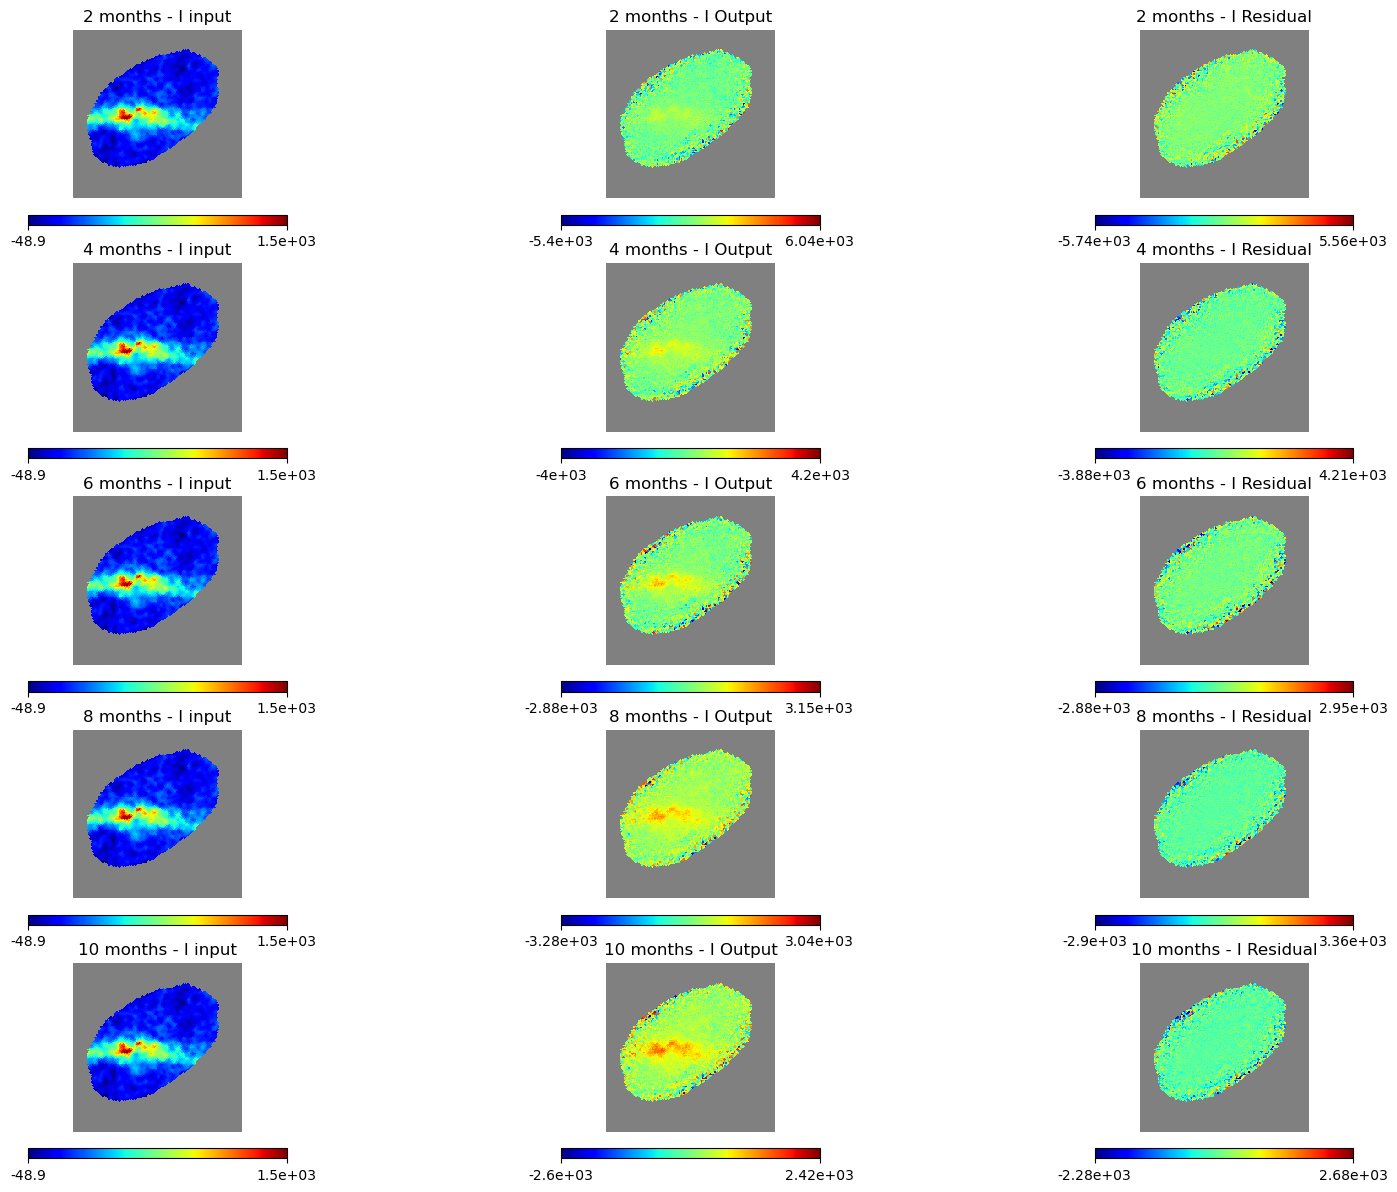

In [ ]:
maps_input = np.mean(data["maps_in_cum"], axis=1)
maps_rec = np.mean(data["maps_cum"], axis=1)
maps_res = np.mean(data["maps_res_cum"], axis=1)
seenpix = data["seenpix_cum"]

maps_input = np.where(seenpix, maps_input, hp.UNSEEN)
maps_rec = np.where(seenpix, maps_rec, hp.UNSEEN)
maps_res = np.where(seenpix, maps_res, hp.UNSEEN)

valid_res = maps_res[i, maps_res[i] != hp.UNSEEN]
sigma_res = np.std(valid_res)

nus = data["nus"]
center = data["center"]
coverage = data["coverage_cum"]

k=0 

plt.figure(figsize=(12,18))
for i in range(len(datafiles)):
    hp.gnomview((maps_input[i, :]), rot=center,
                        reso=15,
                        notext=False,
                        title=f"{i*2+2} months - I input",  
                        cmap="jet",
                        unit=r"$\mu K_{CMB}$",
                        sub=(6, 3, k + 1))
    
    hp.gnomview((maps_rec[i, :]), rot=center,
                        reso=15,
                        notext=False,
                        title=f"{i*2+2} months - I Output",
                        cmap="jet",
                        unit=r"$\mu K_{CMB}$",   
                        sub=(6, 3, k + 2))
    
    hp.gnomview(maps_res[i, :], rot=center,
                        reso=15,
                        notext=False,
                        title=f"{i*2+2} months - I Residual",
                        cmap="jet",
                        min=-3*sigma_res, max=3*sigma_res,
                        unit=r"$\mu K_{CMB}$",
                        sub=(6, 3, k + 3))


    ax = plt.gca()
    ax.text(0.95, 0.95, rf"$\sigma = {sigma:.0f}$",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, weight="bold", color="black",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1.5))
            
    k += 3

Deviazione standard delle mappe dei residui: [844.97423199 606.30447808 494.89508748 434.30525531 382.22956705
 346.2629174 ]
Deviazione standard della media delle mappe dei residui assumendole scorrelate: [844.97424316 597.72485352 493.79650879 432.23947144 386.81838379
 349.12723796]


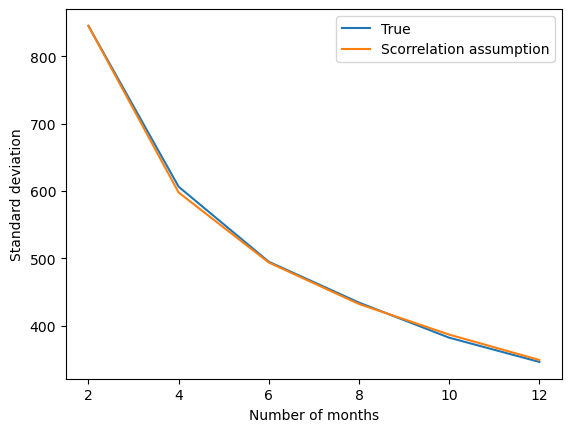

In [ ]:
# Standard deviation from residual maps
stds = []
for i in range(6):
    stds.append(np.std(maps_res[i,seenpix[i]]))

print('Standard deviation of the residual maps:', np.array(stds))
plt.plot(np.arange(2,14,2), stds, label='True')

# Standard deviation of the stackd maps assuming uncorrelation
res = np.mean(data['maps_res'], axis=1)
stds = []
for i in range(6):
    stds.append(np.std(res[i][data['seenpix'][i]]))
stds2 = np.sqrt(np.cumsum(np.array(stds)**2))/np.arange(1,7)

print('Standard deviation of the stackd maps assuming uncorrelation:', stds2)
plt.plot(np.arange(2,14,2), stds2, label='Scorrelation assumption')

plt.xlabel('Number of months')
plt.ylabel('Standard deviation')
plt.legend()

Minimum correlation: 0.031089043861882243
Maximum correlation: 0.10668082646462036


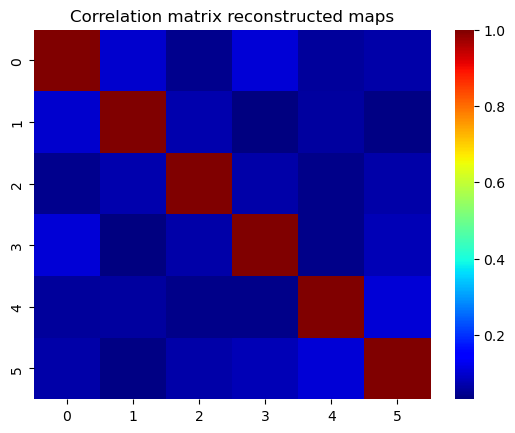

In [7]:
rec = np.mean(data['maps_rec'], axis=1)
idx = np.argmin(np.sum(data['seenpix'], axis=1))
X = np.array([map[data['seenpix'][idx]] for map in rec])

# matrice di correlazione
corr = np.corrcoef(X)

plt.figure()
plt.title('Correlation matrix reconstructed maps')
sns.heatmap(corr, cmap='jet')

print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

Minimum correlation: -0.036234442206550685
Maximum correlation: 0.043280480112246604


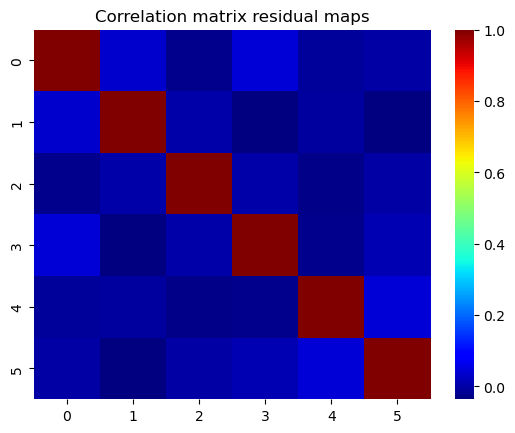

In [8]:
X = np.array([map[data['seenpix'][idx]] for map in res])

# matrice di correlazione
corr = np.corrcoef(X)

plt.figure()
plt.title('Correlation matrix residual maps')
sns.heatmap(corr, cmap='jet')

print('Minimum correlation:', np.min(corr[corr!=1]))
print('Maximum correlation:', np.max(corr[corr<0.99]))

### Noise estimation and SNR maps

<Figure size 1000x500 with 0 Axes>

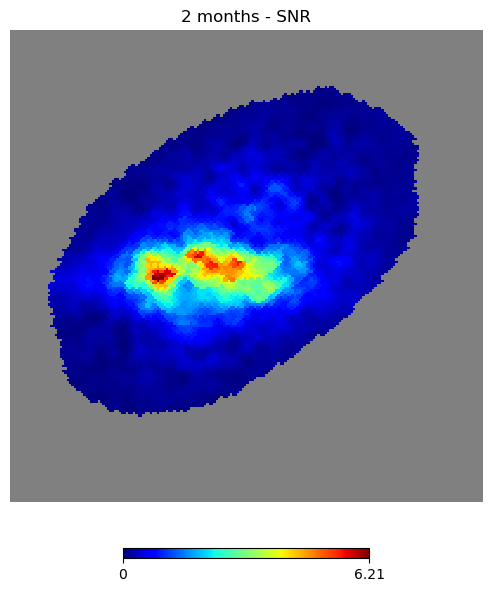

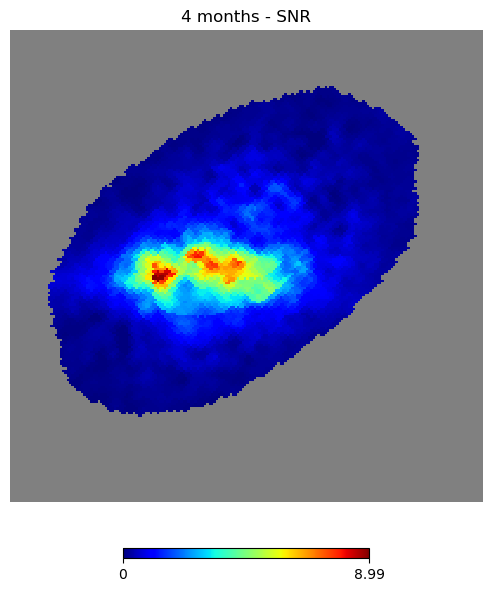

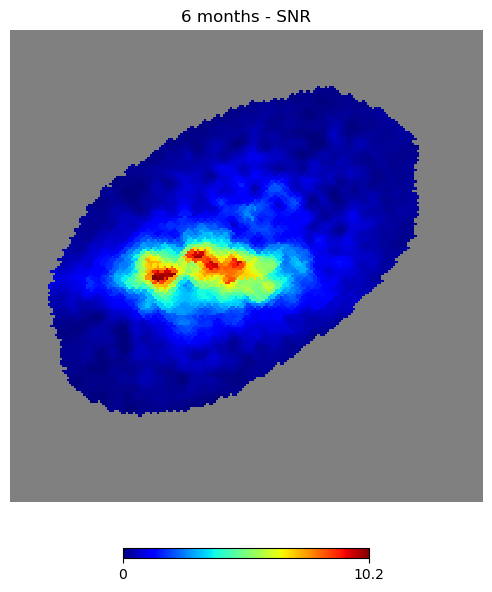

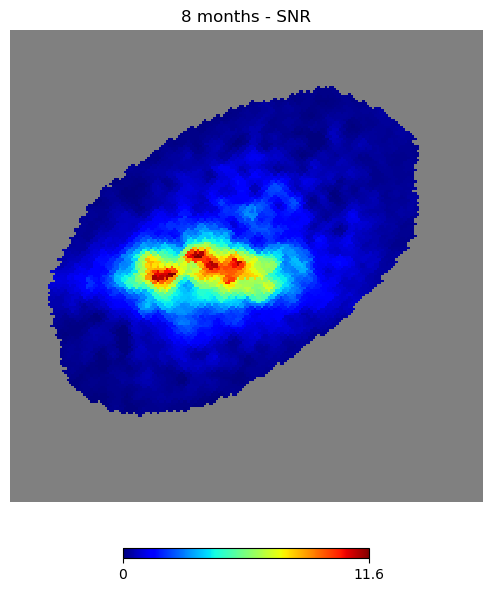

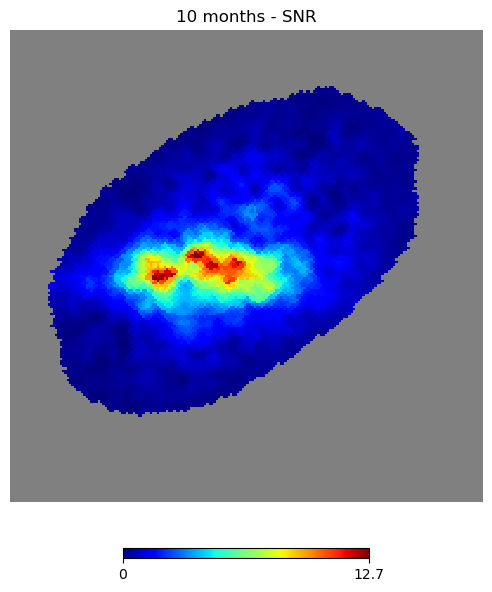

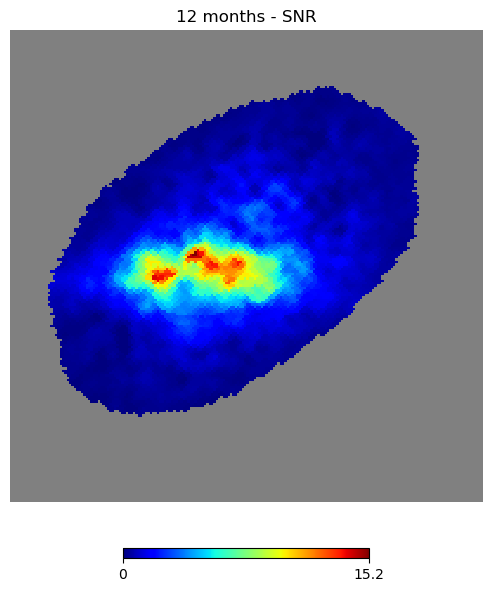

In [ ]:
# SNR computed from the standard deviation of pixels divived into coverage bins
snr_bin = []
for i in range(N):
    snr_bin.append(snr_from_coverage_bins(maps_input[i], maps_res[i], coverage[i], seenpix[i], center, nbins=20, plot=False)[0])

plt.figure(figsize=(10, 5))
for i in range(N):
    snr_bin[i][~seenpix[i]] = hp.UNSEEN
    hp.gnomview(snr_bin[i], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - SNR",  
                        cmap="jet",
                        min = 0,                    
                        )

<Figure size 1000x500 with 0 Axes>

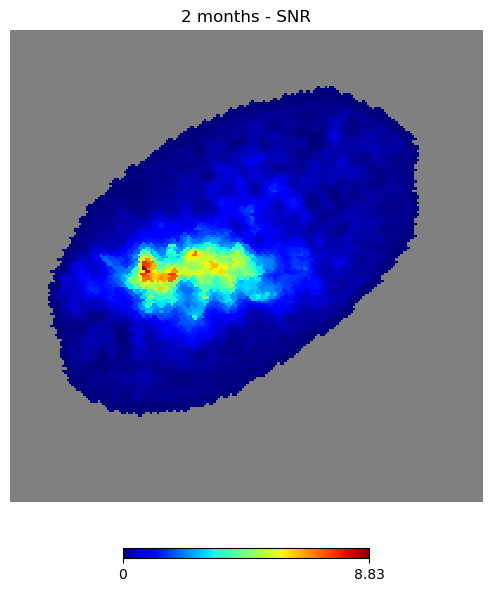

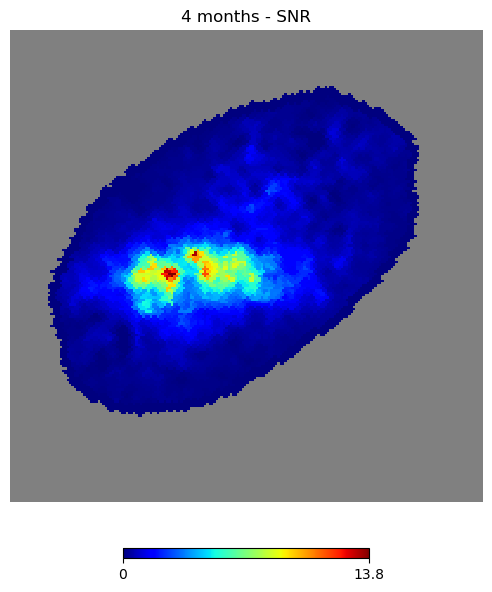

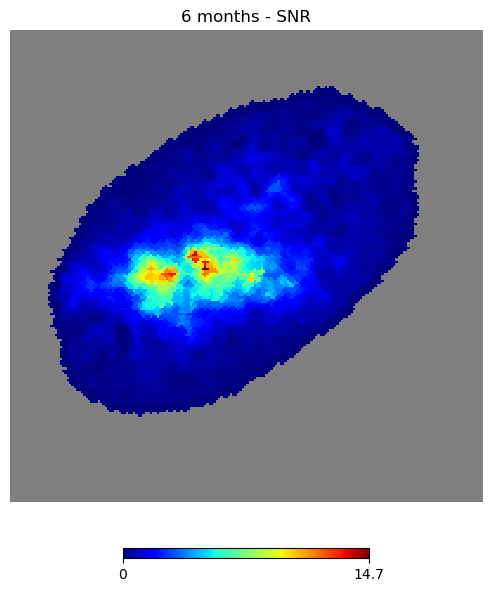

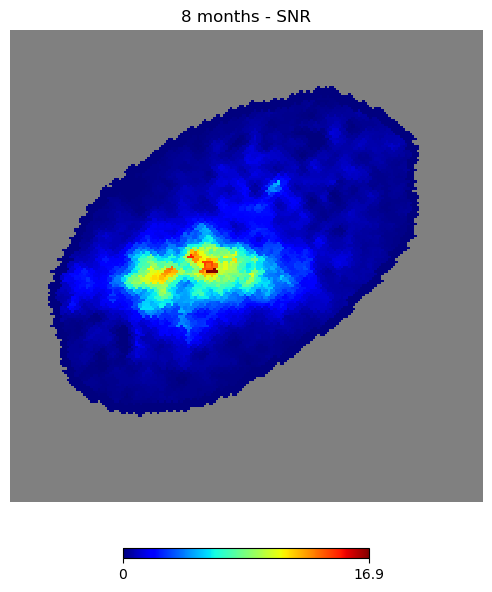

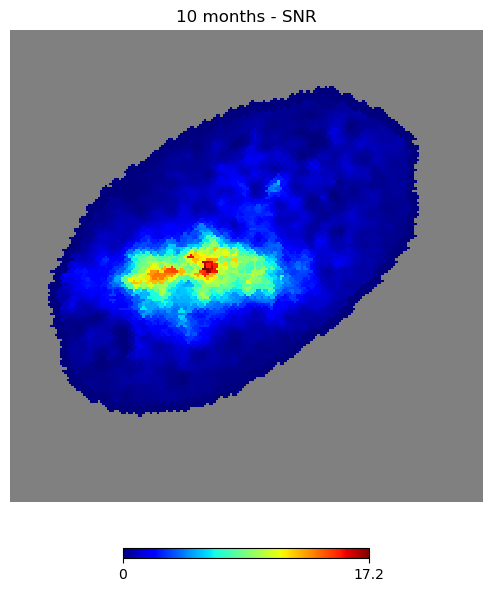

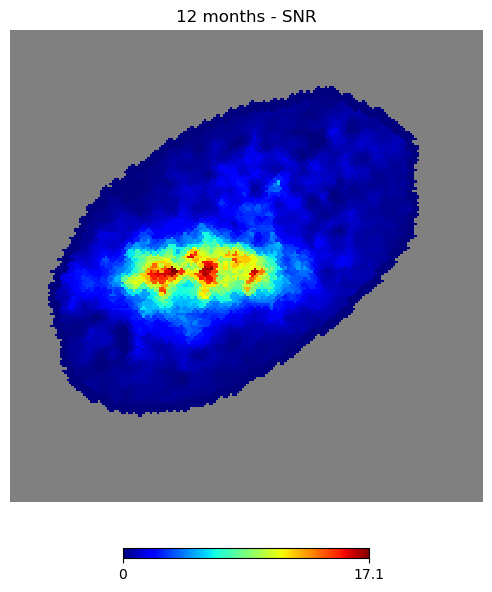

In [ ]:
# SNR computed from local standard deviation
snr_local = []
for i in range(N):
    snr_local.append(calculate_snr2(maps_input[i], maps_res[i], coverage[i], seenpix[i], center, nbins=20, plot=False)[0])

plt.figure(figsize=(10, 5))
for i in range(N):
    snr_local[i][~seenpix[i]] = hp.UNSEEN
    hp.gnomview(snr_local[i], rot=center,
                        reso=15,
                        notext=True,
                        title=f"{i*2+2} months - SNR",  
                        cmap="jet",
                        min = 0,                    
                        )

Text(0, 0.5, 'SNR')

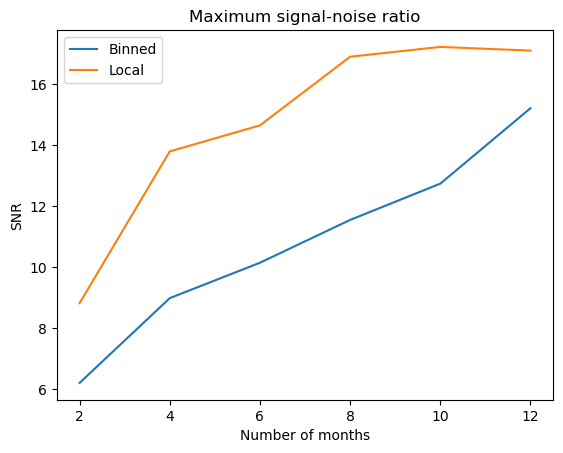

In [11]:
plt.plot(np.arange(2,2*(N+1),2), np.max(snr_bin, axis=1), label='Binned')
plt.plot(np.arange(2,2*(N+1),2), np.max(snr_local, axis=1), label='Local')
plt.title('Maximum signal-noise ratio')
plt.legend()
plt.xlabel('Number of months')
plt.ylabel('SNR')

Text(0, 0.5, 'Percentage')

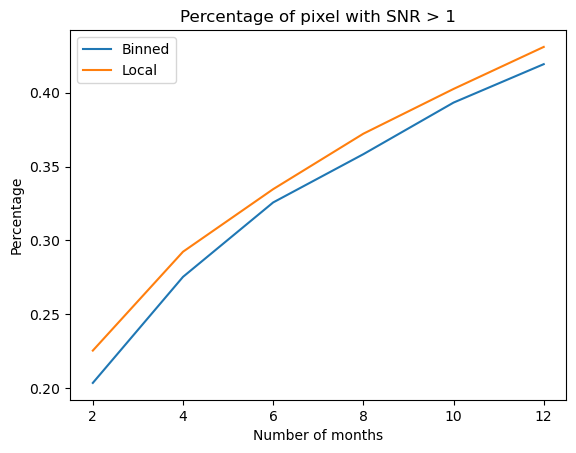

In [12]:
high_snr_bin = []
high_snr_local = []
for i in range(N):
    high_snr_bin.append(np.count_nonzero(snr_bin[i][seenpix[i]] > 1) / len(snr_bin[i][seenpix[i]]))
    high_snr_local.append(np.count_nonzero(snr_local[i][seenpix[i]] > 1) / len(snr_local[i][seenpix[i]]))

plt.plot(np.arange(2,2*(N+1),2), high_snr_bin, label='Binned')
plt.plot(np.arange(2,2*(N+1),2), high_snr_local, label='Local')
plt.title('Percentage of pixel with SNR > 1')
plt.legend()
plt.xlabel('Number of months')
plt.ylabel('Percentage')

In [ ]:
# Save data for comparison
results = {
    "name": "right",
    "h_per_day": np.mean(hours_day),
    "n_pix": {},
    "mean_snr_above": {},
}

for theta in [1, 2, 3]:
    n_pix = []
    mean_snr = []
    for i in range(6):
        valid = snr_bin[i][seenpix[i]]
        above = valid[valid > theta]
        n_pix.append(np.count_nonzero(above))
        mean_snr.append(np.mean(above) if len(above) > 0 else 0.0)
    results["n_pix"][theta]      = np.array(n_pix)
    results["mean_snr_above"][theta] = np.array(mean_snr)

pickle.dump(results, open("right_comparison.pkl", "wb"))

region_name = "right"  
save_dir = "/home/mattia/tesi/data/snr_maps/"
for i in range(6):
    np.save(f"{save_dir}snr_{region_name}_{(i+1)*2}m.npy", snr_bin[i])
    np.save(f"{save_dir}seenpix_{region_name}_{(i+1)*2}m.npy", seenpix[i])

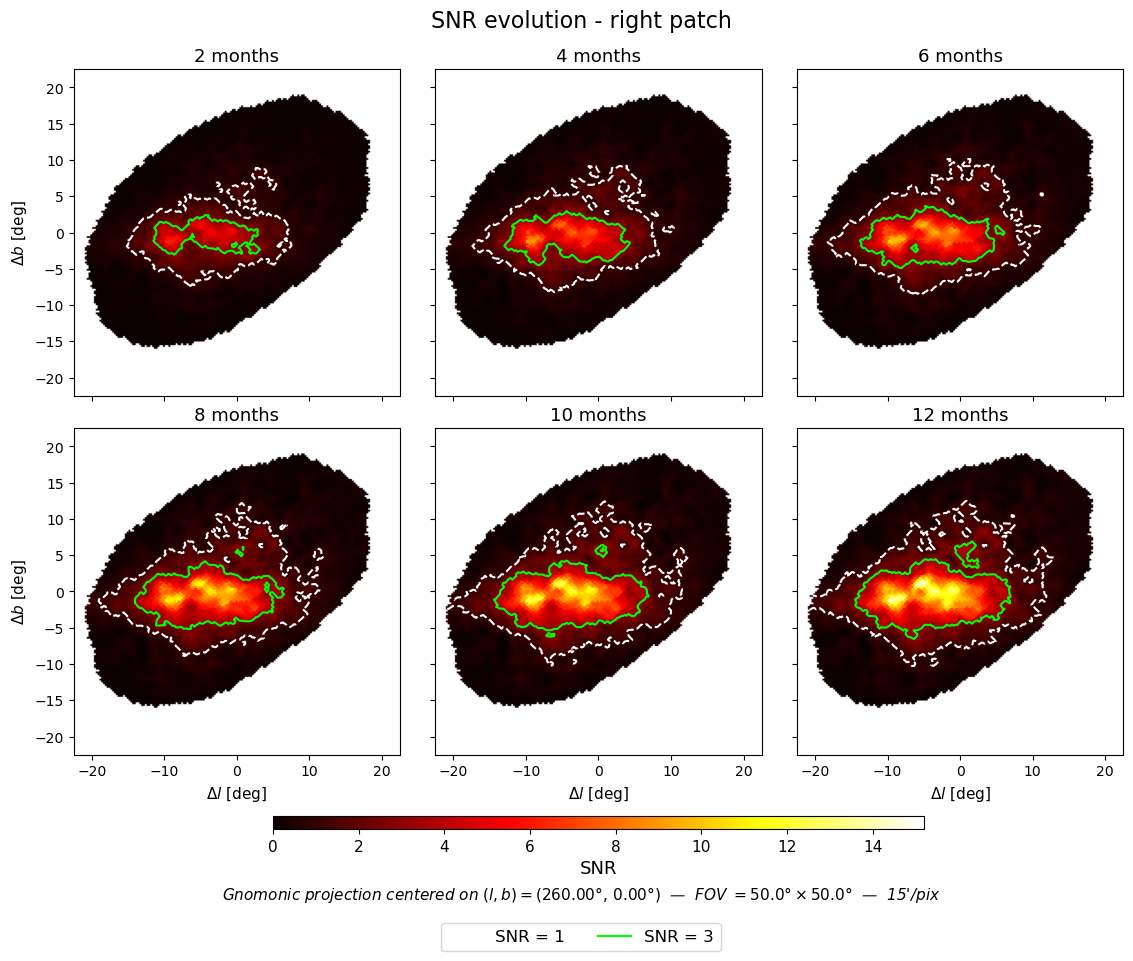

In [8]:
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# ── Configuration ──
region_name = "right"
center = center      # (l, b) galattiche
vmax = 15.2
reso = 15                      # arcmin/pixel
xsize = 200

months_list = [2, 4, 6, 8, 10, 12]
snr_levels = [1, 3]
level_colors = ["white", "lime"]
level_styles = ["--", "-"]

# FOV in gradi
fov = xsize * reso / 60.0
extent = [-fov/2, fov/2, -fov/2, fov/2]  # gradi da centro

# ── Project all maps ──
projected = []
for i in range(6):
    snr_temp = snr_bin[i].copy()
    snr_temp[~seenpix[i]] = hp.UNSEEN
    proj = hp.gnomview(snr_temp, rot=center, reso=reso, xsize=xsize,
                       return_projected_map=True, no_plot=True)
    projected.append(np.ma.masked_equal(proj, hp.UNSEEN))

# ── Plot 2x3 grid ──
fig, axes = plt.subplots(2, 3, figsize=(14, 10),
                         gridspec_kw={"hspace": 0.1, "wspace": 0.})
norm = Normalize(vmin=0, vmax=vmax)

for idx, (ax, month, proj) in enumerate(zip(axes.flat, months_list, projected)):
    im = ax.imshow(proj, origin="lower", cmap="hot", norm=norm, extent=extent)

    ax.contour(proj, levels=snr_levels, colors=level_colors,
               linewidths=1.5, linestyles=level_styles,
               extent=extent, origin="lower")

    ax.set_title(f"{month} months", fontsize=13)
    margin = fov / 2 * 0.9
    ax.set_xlim(-margin, margin)
    ax.set_ylim(-margin, margin)
    #ax.set_xlabel(r"$\Delta l$ [deg]", fontsize=11)
    #ax.set_ylabel(r"$\Delta b$ [deg]", fontsize=11)
    ax.tick_params(labelsize=10)
    # Label solo sui bordi esterni
    if idx % 3 == 0:
        ax.set_ylabel(r"$\Delta b$ [deg]", fontsize=11)
    else:
        ax.set_yticklabels([])
    if idx >= 3:
        ax.set_xlabel(r"$\Delta l$ [deg]", fontsize=11)
    else:
        ax.set_xticklabels([])

# Annotazione centro sotto la riga inferiore
fig.text(0.5, 0.05,
         rf"Gnomonic projection centered on $(l, b) = ({center[0]:.2f}°,\, {center[1]:.2f}°)$"
         rf"  —  FOV $= {fov:.1f}° \times {fov:.1f}°$  —  {reso}'/pix",
         ha="center", fontsize=11, style="italic")

# Colorbar
cbar = fig.colorbar(im, ax=axes, orientation="horizontal",
                    fraction=0.03, pad=0.08, aspect=50, shrink=0.6)
cbar.set_label("SNR", fontsize=13)
cbar.ax.tick_params(labelsize=11)

# Legenda contorni
legend_handles = [Line2D([0], [0], color=c, ls=ls, lw=1.5,
                         label=rf"SNR = {l}")
                  for l, c, ls, in zip(snr_levels, level_colors, level_styles)]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=12, frameon=True, bbox_to_anchor=(0.5, -0.01))

fig.suptitle(f"SNR evolution - {region_name} patch", fontsize=16, y=0.94)

plt.savefig(f"/home/mattia/tesi/tesi/figures/snr_maps_{region_name}.pdf", bbox_inches="tight")